<a href="https://colab.research.google.com/github/EmmanuelEjima/Data-Science-Machine-Learning-Portfolio/blob/main/Titanic_Survival_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
%matplotlib inline


In [3]:
# 2. Load the dataset
from google.colab import files

uploaded = files.upload()


Saving Titanic Dataset.csv to Titanic Dataset (1).csv


In [4]:
EDA = pd.read_csv('Titanic Dataset.csv')
print(f"Dataset Shape: {EDA.shape}")
EDA.head()
EDA.info()

Dataset Shape: (1309, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-

In [5]:
# 1. Check for missing values
missing_values = EDA.isnull().sum()
missing_percentage = (EDA.isnull().sum() / len(EDA)) * 100
missing_EDA = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
print(missing_EDA[missing_EDA['Missing Values'] > 0])

# 2. Check for duplicate rows
print(f"Duplicate rows found: {EDA.duplicated().sum()}")

          Missing Values  Percentage (%)
Embarked               2        0.152788
Duplicate rows found: 0


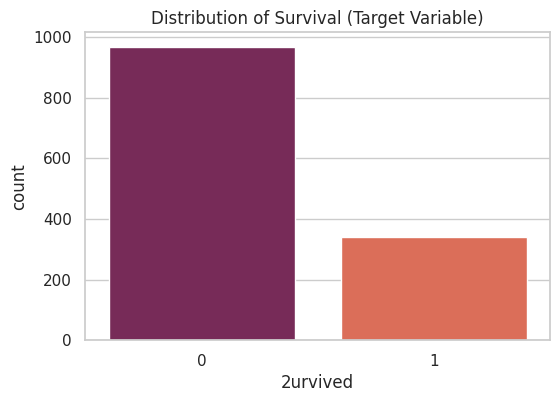

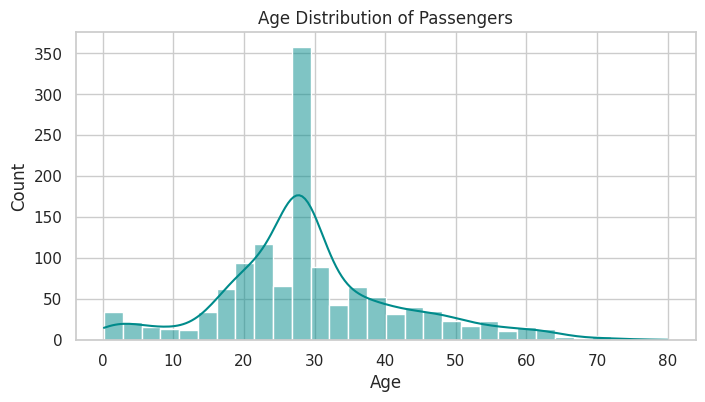

In [6]:
# 1. Statistical summary of numerical columns
EDA.describe()

# 2. Plotting Target Variable distribution (2urvived / Survived)
plt.figure(figsize=(6, 4))
sns.countplot(data=EDA, x='2urvived', hue='2urvived', palette='rocket', legend=False)
plt.title('Distribution of Survival (Target Variable)')
plt.show()

# 3. Plotting Continuous Variable distribution (Age)
plt.figure(figsize=(8, 4))
sns.histplot(data=EDA, x='Age', kde=True, bins=30, color='darkcyan')
plt.title('Age Distribution of Passengers')
plt.show()

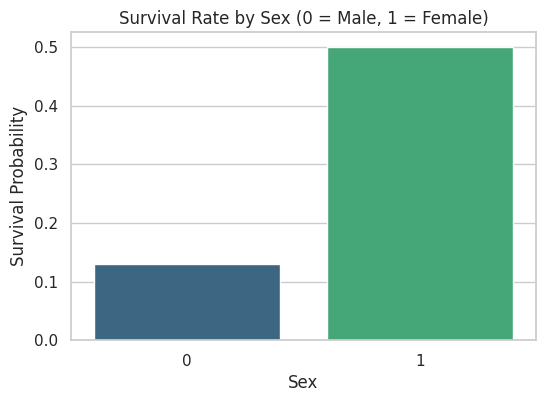

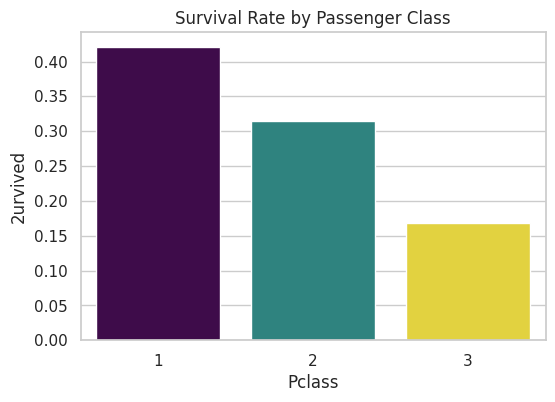

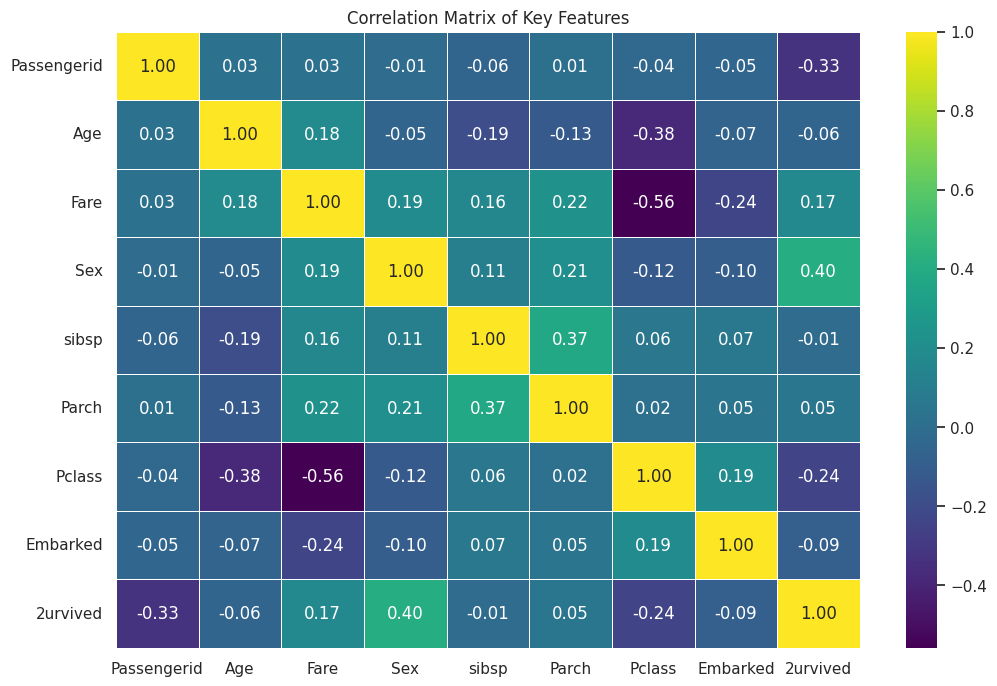

In [7]:
# 1. Relationship between Categorical Feature (Sex) and Target (2urvived)
plt.figure(figsize=(6, 4))
sns.barplot(data=EDA, x='Sex', y='2urvived', hue='Sex', errorbar=None, palette='viridis', legend=False)
plt.title('Survival Rate by Sex (0 = Male, 1 = Female)')
plt.ylabel('Survival Probability')
plt.show()

# 2. Relationship between Passenger Class (Pclass) and Target
plt.figure(figsize=(6, 4))
sns.barplot(data=EDA, x='Pclass', y='2urvived', hue='Pclass', errorbar=None, palette='viridis', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.show()

# 3. Correlation Heatmap (To find linear relationships)
plt.figure(figsize=(12, 8))
# Filtering out columns named 'zero' to keep the heatmap clean
clean_cols = [col for col in EDA.columns if 'zero' not in col]
sns.heatmap(EDA[clean_cols].corr(), annot=True, fmt=".2f", cmap='viridis', linewidths=0.5)
plt.title('Correlation Matrix of Key Features')
plt.show()

## Summary & Insights

Based on the exploratory data analysis, here are some initial insights:

*   **Survival Distribution**: A significant portion of passengers did not survive, indicating a challenging survival scenario.
*   **Survival Rate by Sex**: Females (represented as `Sex=1`) had a notably higher survival rate compared to males (represented as `Sex=0`). This suggests gender was a significant factor in survival probability.
*   **Survival Rate by Passenger Class**: Passengers in first-class (`Pclass=1`) exhibited a higher survival probability than those in second (`Pclass=2`) and especially third-class (`Pclass=3`). This indicates that socio-economic status, as reflected by passenger class, played a role in survival outcomes.